Week 5 task 1

In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix

from imblearn.over_sampling import SMOTE

In [3]:
df=pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
df.shape

(61491, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61491 entries, 0 to 61490
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    61491 non-null  int64  
 1   V1      61491 non-null  float64
 2   V2      61491 non-null  float64
 3   V3      61491 non-null  float64
 4   V4      61491 non-null  float64
 5   V5      61491 non-null  float64
 6   V6      61491 non-null  float64
 7   V7      61491 non-null  float64
 8   V8      61491 non-null  float64
 9   V9      61491 non-null  float64
 10  V10     61491 non-null  float64
 11  V11     61491 non-null  float64
 12  V12     61491 non-null  float64
 13  V13     61491 non-null  float64
 14  V14     61491 non-null  float64
 15  V15     61491 non-null  float64
 16  V16     61491 non-null  float64
 17  V17     61491 non-null  float64
 18  V18     61491 non-null  float64
 19  V19     61491 non-null  float64
 20  V20     61491 non-null  float64
 21  V21     61491 non-null  float64
 22

In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [11]:
df.columns=df.columns.str.strip()

In [12]:
df["Class"].value_counts()

,count
Class,
0.0,61327
1.0,163


In [13]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0.0,99.734916
1.0,0.265084


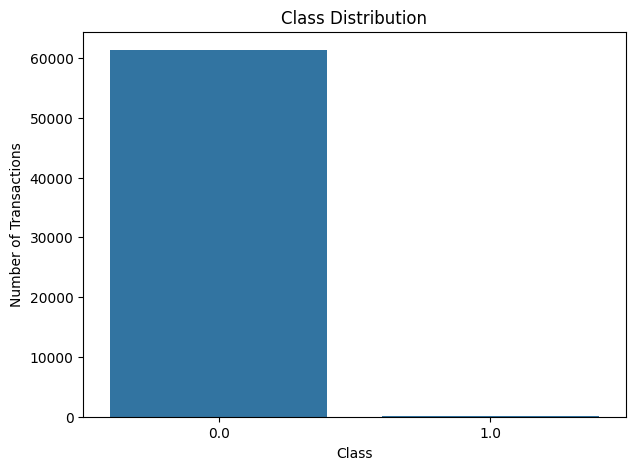

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

The dataset is highly imbalanced. The majority class represents normal transactions, while fraudulent transactions make up only a very small portion of the dataset. This imbalance can cause a machine learning model to favor the majority class and perform poorly at detecting fraud.

In [15]:
X = df.drop('Class', axis=1)
y = df['Class']

In [17]:
X.shape,y.shape

((61491, 30), (61491,))

In [19]:
df = df.dropna(subset=['Class'])

In [21]:
df = df.dropna(subset=['Class'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test_scaled)

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     12265
         1.0       0.66      0.70      0.68        33

    accuracy                           1.00     12298
   macro avg       0.83      0.85      0.84     12298
weighted avg       1.00      1.00      1.00     12298



In [26]:
precision_before = precision_score(y_test, y_pred)
recall_before = recall_score(y_test, y_pred)
f1_before = f1_score(y_test, y_pred)
print("Precision:", precision_before)
print("Recall:", recall_before)
print("F1 Score:", f1_before)

Precision: 0.6571428571428571
Recall: 0.696969696969697
F1 Score: 0.6764705882352942


In [27]:
smote = SMOTE(random_state=42)

In [28]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [29]:
print(y_train_smote.value_counts())

Class
0.0    49062
1.0    49062
Name: count, dtype: int64


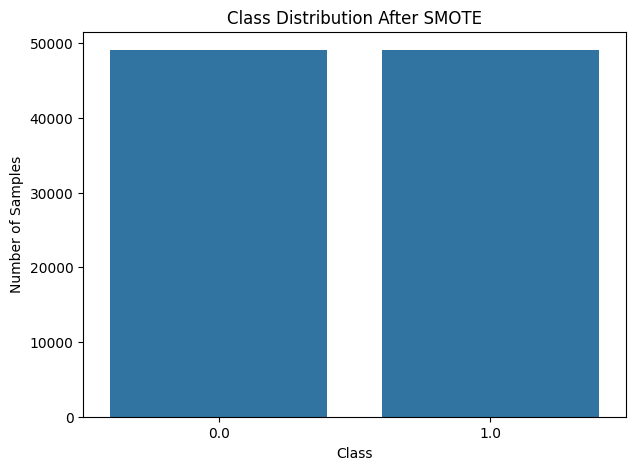

In [30]:
plt.figure(figsize=(7,5))
sns.countplot(x=y_train_smote)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.show()

In [31]:
model_smote = LogisticRegression(max_iter=1000)

model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [32]:
y_pred_smote = model_smote.predict(X_test_scaled)

In [33]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     12265
         1.0       0.12      0.88      0.21        33

    accuracy                           0.98     12298
   macro avg       0.56      0.93      0.60     12298
weighted avg       1.00      0.98      0.99     12298



In [34]:
precision_after = precision_score(y_test, y_pred_smote)
recall_after = recall_score(y_test, y_pred_smote)
f1_after = f1_score(y_test, y_pred_smote)

print("Precision:", precision_after)
print("Recall:", recall_after)
print("F1 Score:", f1_after)

Precision: 0.12236286919831224
Recall: 0.8787878787878788
F1 Score: 0.21481481481481482


In [35]:
comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score'],
    'Before SMOTE': [
        precision_before,
        recall_before,
        f1_before
    ],
    'After SMOTE': [
        precision_after,
        recall_after,
        f1_after
    ]
})

comparison

,Metric,Before SMOTE,After SMOTE
0,Precision,0.657143,0.122363
1,Recall,0.696970,0.878788
2,F1 Score,0.676471,0.214815


The Credit Card Fraud Detection dataset was highly imbalanced, with fraudulent transactions representing a very small portion of the data. A Logistic Regression model was trained before and after applying SMOTE. The results were compared using Precision, Recall, and F1-score.
SMOTE helped address the class imbalance by generating synthetic samples for the minority class. The comparison showed how balancing the training data affected the model's ability to detect fraudulent transactions. Accuracy alone was not considered sufficient because a model could achieve high accuracy by mainly predicting the majority class.